1. Title of the database: "N-BaIoT: Data for network based detection of IoT botnet attacks"

2. Source Information
   -- Creators: Yair Meidan, Michael Bohadana, Yael Mathov, Yisroel Mirsky, Dominik Breitenbacher, Asaf Shabtai and Yuval Elovici
     -- Meidan, Bohadana, Mathov, Mirsky, Shabtai: Department of Software and Information Systems Engineering; Ben-Gurion University of the Negev; Beer-Sheva, 8410501; Israel
	 -- Breitenbacher, Elovici: iTrust Centre of Cybersecurity at Singapore University of Technology and Design; 8 Somapah Rd, Singapore 487372
   -- Donor: Yair Meidan (yairme@bgu.ac.il)
   -- Date: March, 2018 (databases may change over time without name change!)

3. Past Usage:
    (a) Please cite the following papers:
		-- Reference to the article where it was initially described and used:
			-- Y. Meidan, M. Bohadana, Y. Mathov, Y. Mirsky, D. Breitenbacher, A. Shabtai, and Y. Elovici "N-BaIoT: Network-based Detection of IoT Botnet Attacks Using Deep Autoencoders", IEEE Pervasive Computing, Special Issue - Securing the IoT (July/Sep 2018).
		-- Reference to the article where the feature extractor (from *.pcap to *.csv) was described:
			-- Y. Mirsky, T. Doitshman, Y. Elovici & A. Shabtai 2018, "Kitsune: An Ensemble of Autoencoders for Online Network Intrusion Detection", in Network and Distributed System Security (NDSS) Symposium, San Diego, CA, USA.
	(b) Attribute being predicted:
		-- Originally we aimed at distinguishing between benign and Malicious traffic data by means of anomaly detection techniques.
		-- However, as the malicious data can be divided into 10 attacks carried by 2 botnets, the dataset can also be used for multi-class classification: 10 classes of attacks, plus 1 class of "benign".
	(c) The study's results:
		-- For each of the 9 IoT devices we trained and optimized a deep autoencoder on 2/3 of its benign data (i.e., the training set of each device). This was done to capture normal network traffic patterns.
        -- The test data of each device comprised of the remaining 1/3 of benign data plus all the malicious data. On each test set we applied the respective trained (deep) autoencoder as an anomaly detector. The detection of anomalies (i.e., the cyberattacks launched from each of the above IoT devices) concluded with 100% TPR.  
	      
4. Relevant Information:
   -- This dataset addresses the lack of public botnet datasets, especially for the IoT.
   -- Prior experimental studies on the detection of IoT botnets or IoT traffic anomalies typically relied on emulated or simulated data. In contrary , this dataset enables empirical evaluation with *real* traffic data, gathered from nine commercial IoT devices infected by authentic botnets from two families in an isolated network. It facilitates the examination of Mirai and BASHLITE, two of the most common IoT-based botnets, which have already demonstrated their harmful capabilities.

5. Number of Instances: Varies for every device and attack.

6. Number of Attributes: 115 independent features in each file, plus a class label to be derived from the respective filename (e.g., "benign" or "TCP attack").

7. Attribute Information:
	-- The following describes each of the features headers:
		-- Stream aggregation:
			H: ("Source IP" in N-BaIoT paper) Stats summarizing the recent traffic from this packet's host (IP)
			MI: ("Source MAC-IP" in N-BaIoT paper) Stats summarizing the recent traffic from this packet's host (IP + MAC)
			HH: ("Channel" in N-BaIoT paper) Stats summarizing the recent traffic going from this packet's host (IP) to the packet's destination host.
			HH_jit: ("Channel jitter" in N-BaIoT paper) Stats summarizing the jitter of the traffic going from this packet's host (IP) to the packet's destination host.
			HpHp: ("Socket" in N-BaIoT paper) Stats summarizing the recent traffic going from this packet's host+port (IP) to the packet's destination host+port. Example 192.168.4.2:1242 -> 192.168.4.12:80
		-- Time-frame (The decay factor Lambda used in the damped window):
			-- How much recent history of the stream is capture in these statistics
			-- L5, L3, L1, L0.1 and L0.01
		-- The statistics extracted from the packet stream:
			weight: The weight of the stream (can be viewed as the number of items observed in recent history)
			mean: ...
			std: ...
			radius: The root squared sum of the two streams' variances
			magnitude: The root squared sum of the two streams' means
			cov: An approximated covariance between two streams
			pcc: An approximated correlation coefficient between two streams
      

Great—this is a **clean, class-friendly pipeline** using only:

* **SimpleHome_XCS7_1002_WHT_Security_Camera**
* **Ecobee Thermostat**

and **KNN** 👍

---

# 🔷 Step-by-Step Pipeline (KNN – Your Selected Devices)

## 1. Data Selection

* Use only:

  * SimpleHome camera dataset
  * Ecobee thermostat dataset
* Each contains:

  * Benign traffic
  * Multiple attack types

---

## 2. Load Data

* Read all CSV files from both devices
* Combine into one dataset

```python
import pandas as pd

df1 = pd.read_csv("SimpleHome.csv")
df2 = pd.read_csv("Ecobee.csv")

df = pd.concat([df1, df2])
```

---

## 3. Label Creation

* Extract label from filename or assign manually:

  * **benign → 0**
  * **attack → 1**

```python
df['label'] = df['label'].apply(lambda x: 0 if x=='benign' else 1)
```

---

## 4. Feature & Target Split

```python
X = df.drop('label', axis=1)
y = df['label']
```

---

## 5. Data Preprocessing

### 🔹 5.1 Handle Missing Values

```python
X = X.fillna(0)
```

### 🔹 5.2 Feature Scaling (VERY IMPORTANT for KNN)

```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
```

---

## 6. Train-Test Split

* Use stratified split (keeps class balance)

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)
```

---

## 7. Train KNN Model

### 👉 K-Nearest Neighbors

```python
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
```

---

## 8. Prediction

```python
y_pred = model.predict(X_test)
```

---

## 9. Evaluation

```python
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
```

---

## 10. Hyperparameter Tuning (Optional but Recommended ⭐)

Try different K values:

```python
for k in [3,5,7,9]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    print(k, model.score(X_test, y_test))
```

---

## 🔷 Final Flow (Simple View)

```
Select Devices (2 datasets)
        ↓
Load & Merge Data
        ↓
Create Labels (0 = benign, 1 = attack)
        ↓
Preprocess (fill NA + scale)
        ↓
Train-Test Split
        ↓
Train KNN Model
        ↓
Predict
        ↓
Evaluate Performance
```

---

## 🔥 Tip for Your Submission

* Mention:

  * Why KNN → simple, interpretable
  * Why scaling → distance-based model
  * Why 2 devices → controlled experiment

---

If you want, I can next:
✅ Turn this into a **report (Methodology section)**
✅ Or give you **plots + results interpretation (for A grade)**


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Change file path depending on local machine
# Creating a shortcut link (BASH commands)
!ln -s "/content/drive/MyDrive/Mirai_project/data" /content/mirai

!rm -rf /content/mirai
!ln -s "/content/drive/MyDrive/Mirai_project/data" /content/mirai

from pathlib import Path
BASE_PATH = Path("/content/mirai")

print(list(BASE_PATH.iterdir()))  # should show Device1, Device2

Mounted at /content/drive
[PosixPath('/content/mirai/Ecobee_Thermostat'), PosixPath('/content/mirai/SimpleHome_XCS7_1002_WHT_Security_Camera')]


In [ ]:
## START RUNNING CODE SEGMENTS FROM HERE

import pandas as pd
from pathlib import Path

BASE_PATH = Path("/content/mirai")

def load_mirai_dataset(base_path):
    for device_dir in base_path.iterdir():
        if not device_dir.is_dir():
            continue

        device_name = device_dir.name

        # --- BENIGN FILES ---
        # any .csv files in the device directory
        for file in device_dir.glob("*.csv"):
            df = pd.read_csv(file)

            df["device"] = device_name
            df["label"] = "benign"
            df["attack_type"] = "benign"

            yield df


        # --- ATTACK FILES ---
        attack_dir = device_dir / "mirai_attacks"

        if attack_dir.exists():
            # any .csv files in mirai_attack directory
            for file in attack_dir.glob("*.csv"):
                df = pd.read_csv(file)

                attack_type = file.stem  # ack, scan, etc.

                df["device"] = device_name
                df["label"] = "attack"
                df["attack_type"] = attack_type

                yield df

# Combine everything
df = pd.concat(load_mirai_dataset(BASE_PATH), ignore_index=True)

In [ ]:
# Viewing combined dataset (benign and attack)
import pandas as pd


print(df["device"].value_counts(), "\n")
print(df["label"].value_counts(), "\n")
print(df["attack_type"].value_counts())

device
SimpleHome_XCS7_1002_WHT_Security_Camera    559833
Ecobee_Thermostat                           525246
Name: count, dtype: int64 

label
attack    1025381
benign      59698
Name: count, dtype: int64 

attack_type
udp         303360
syn         242522
ack         224765
udpplain    165612
scan         89122
benign       59698
Name: count, dtype: int64


In [ ]:
# Label Creation 0 = benign, 1 = attack
df['label'] = df['label'].str.lower().map({'benign': 0, 'attack': 1})

# Feature Selection
X = df.drop(columns=['label', 'device', 'attack_type'], errors='ignore')
y = df['label']

# Handle missing values
X = X.fillna(X.median())

In [ ]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Train - Test Split
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Reduce the training data to 50,000 samples
# Keeps the same class ratio which is imbalanced
X_train, y_train = resample(X_train, y_train,
                            n_samples=50000,
                            random_state=42
                            ,stratify=y_train)


In [ ]:
# Make a balanced dataset between benign and attack sample points
# Using Undersampling

import pandas as pd

df_train = pd.DataFrame(X_train)
df_train['label'] = y_train.values  # ensure alignment

# --- Separate classes ---
benign = df_train[df_train['label'] == 0]
attack = df_train[df_train['label'] == 1]

print("Before balancing:")
print(df_train['label'].value_counts())

# --- Undersample majority class ---
attack_downsampled = attack.sample(
    n=len(benign),   # match minority class
    random_state=42
)

# --- Combine into balanced dataset ---
df_balanced = pd.concat([benign, attack_downsampled])

# --- Shuffle ---
df_balanced = df_balanced.sample(frac=1, random_state=42)

# --- Split back ---
X_train_bal = df_balanced.drop('label', axis=1).values
y_train_bal = df_balanced['label'].values

print("\nAfter balancing:")
print(pd.Series(y_train_bal).value_counts())

Before balancing:
label
1    47249
0     2751
Name: count, dtype: int64

After balancing:
1    2751
0    2751
Name: count, dtype: int64


In [ ]:
# This will train and predict from (sampled) BALANCED dataset

from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_bal, y_train_bal)

y_pred_bal = model.predict(X_test)

In [ ]:
# This will train and predict from (sampled) UNBALANCED dataset

# Train kNN
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5, weights='distance')
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

In [ ]:
# Evaluation (UNBALANCED)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy (IMBALANCED):", accuracy_score(y_test, y_pred), '\n')
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred) , '\n')
# [[True Neg, False Posi] [False Neg, True Posi]]
# We must be carefull because of dataset imbalance


# Evaluation (BALANCED)
print("Accuracy (BALANCED):", accuracy_score(y_test, y_pred_bal), '\n')
print(classification_report(y_test, y_pred_bal))
print(confusion_matrix(y_test, y_pred_bal))


# My OBSERVATIONS
# The model performs very well regardless of balanced or unbalanced trained models
# because classes are well seperated (seen in kNN boundary graph)
# The test_set will remain unbalanced to replicate the real world

# GPT: “Although class balancing was applied to the training data, the evaluation
# metrics remained unchanged. This suggests that the dataset is highly separable
# and the KNN model is able to effectively distinguish between benign and attack
# traffic regardless of class imbalance. Additionally, the test set was
# intentionally left imbalanced to reflect real-world conditions.”

Accuracy (IMBALANCED): 0.9995852840343569 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11940
           1       1.00      1.00      1.00    205076

    accuracy                           1.00    217016
   macro avg       1.00      1.00      1.00    217016
weighted avg       1.00      1.00      1.00    217016

[[ 11883     57]
 [    33 205043]] 

Accuracy (BALANCED): 0.998797323699635 

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     11940
           1       1.00      1.00      1.00    205076

    accuracy                           1.00    217016
   macro avg       0.99      1.00      0.99    217016
weighted avg       1.00      1.00      1.00    217016

[[ 11940      0]
 [   261 204815]]


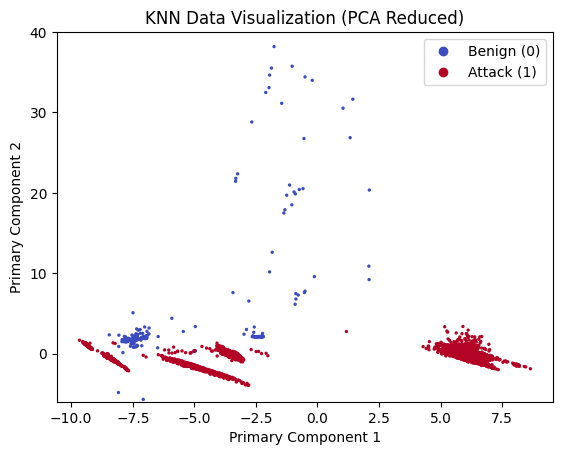

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Smaller sample for visualization

df_small = df.sample(n=5000, random_state=42)
X_small = X_scaled[df_small.index]
y_small = y[df_small.index]


# Reduce to 2 dimensions by extracting the Principal Components
# Principle component is a weighted combination of all features
# Features make N-dimensional space
# 2 Dimensional space best for scatter plotting

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_small)

# Train KNN on reduced data (for visualization only)
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_pca, y_small)

# Plot points
plt.figure()

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_small, s=2, cmap='coolwarm')

handles, _ = scatter.legend_elements()
labels = ['Benign (0)', 'Attack (1)']
plt.legend(handles, labels)


plt.title("KNN Data Visualization (PCA Reduced)")
plt.xlabel("Primary Component 1") # Principle Component 1
plt.ylabel("Primary Component 2")

# Zoom in on the PC2 side by adjusting y-axis limits
plt.ylim(-6, 40)
plt.show()


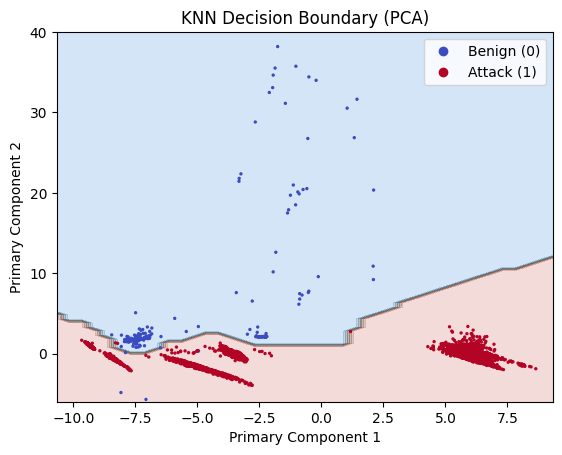

In [ ]:
import numpy as np

h = 0.5  # step size

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3, cmap='berlin')

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_small, s=2, cmap='coolwarm')

handles, _ = scatter.legend_elements()
labels = ['Benign (0)', 'Attack (1)']
plt.legend(handles, labels)

plt.title("KNN Decision Boundary (PCA)")
plt.xlabel("Primary Component 1") #Primary Component 1
plt.ylabel("Primary Component 2")


plt.ylim(-6, 40)
plt.show()


# MY Observations
# There is a smooth decision boundary with some overlapping sample points
# This is just a 2D representation not the true model boundary.

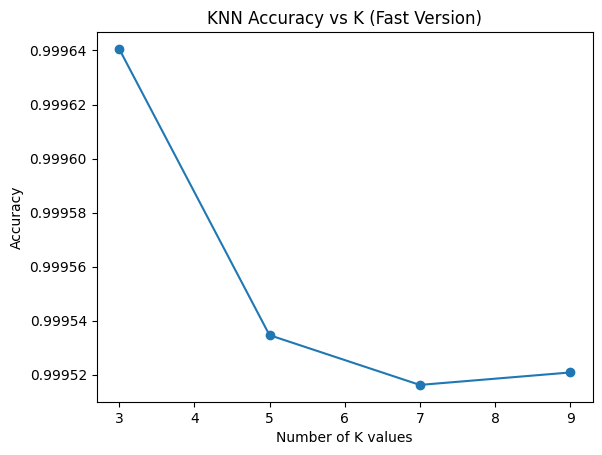

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [3, 5, 7, 9]
scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

# Plot
import matplotlib.pyplot as plt

plt.figure()
plt.plot(k_values, scores, marker='o')
plt.title("KNN Accuracy vs K (Fast Version)")
plt.xlabel("Number of K values")
plt.ylabel("Accuracy")
plt.show()

# k=3 has the best accuracy